# Metode Numeris: Regresi
* Nama  : Alfian Daffa Baihaqi
* NIU   : 25/570509/PTK/16981
* Prodi : Magister Teknik Elektro

### Membandingkan metode regresi linear: 
1. Regresi Linear
$$
f(x) = a + bx
$$
2. Regresi Nonlinear (Kuadratik / Polinomial Orde 2)
$$
f(x) = a + bx + cx^2
$$
3. Regresi Nonlinear
$$
f(x) = a \ln(x) + b \cos(x) + c e^x
$$
### Data yang digunakan
| No |   x   |    y    |
|----|------:|--------:|
| 1  | 0.24  |  0.23   |
| 2  | 0.65  | -0.23   |
| 3  | 0.95  | -1.10   |
| 4  | 1.24  | -0.45   |
| 5  | 1.73  |  0.27   |
| 6  | 2.01  |  0.10   |
| 7  | 2.23  | -0.29   |
| 8  | 2.52  |  0.24   |

In [45]:
import numpy as np
import matplotlib.pyplot as plt

Definisikan metode eliminasi gauss untuk menyelesaikan sistem persamaan

In [46]:
# Fungsi Gauss Elimination
def gauss_elimination(A, b):
    A = A.astype(float)
    b = b.astype(float)
    n = len(b)

    print("Augmented matrix awal:")
    print(np.column_stack((A, b)))
    print()

    # Forward elimination
    for i in range(n - 1):
        for j in range(i + 1, n):
            factor = A[j, i] / A[i, i]
            A[j] -= factor * A[i]
            b[j] -= factor * b[i]
            print(f"R{j+1} = R{j+1} - ({factor:.3f})R{i+1}")
        print("Matrix setelah eliminasi:")
        print(np.column_stack((A, b)))
        print()

    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.dot(A[i][i+1:], x[i+1:])) / A[i][i]

    return x

### Data
Definisikan Arrray Data. Kemudian plot data menggunakan scatter plot untuk memberikan intuisi terkait persebaran data. 

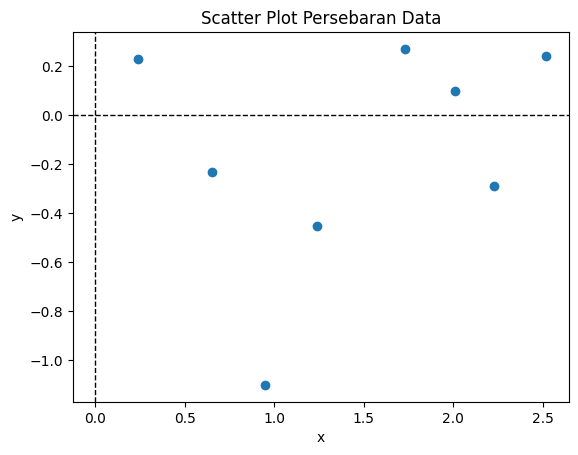

In [47]:
# Definisikan Data
x = np.array([0.24, 0.65, 0.95, 1.24, 1.73, 2.01, 2.23, 2.52])
y = np.array([0.23, -0.23, -1.1, -0.45, 0.27, 0.1, -0.29, 0.24])
n = len(x)

# Scatter plot|
plt.figure()
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot Persebaran Data")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.show()

## Regresi Linear

Model:
$$
f(x) = a + bx
$$

Fungsi Error (Least Squares). Turunan parsial terhadap parameter:
$$
\frac{\partial \Phi(a,b)}{\partial a} = \sum_{i=1}^{n} 2(a + b x_i - y_i) = 0
$$
$$
\frac{\partial \Phi(a,b)}{\partial b} = \sum_{i=1}^{n} 2(a + b x_i - y_i)x_i = 0
$$

Persamaan Normal. Diperoleh sistem persamaan:
$$
n a + \left(\sum x_i \right) b = \sum y_i
$$

$$
\left(\sum x_i \right) a + \left(\sum x_i^2 \right) b = \sum x_i y_i
$$

Maka, hitung komponen berikut:
$$\sum x_i, \sum y_i, \sum x_i^2, dan \sum x_i y_i$$

In [48]:
def linear_regression(x, y):
    n = len(x)
    # Komponen
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x**2)
    sum_xy = np.sum(x * y)
    
    A = np.array([
        [n, sum_x],
        [sum_x, sum_x2]
    ])
    b_vec = np.array([sum_y, sum_xy])
    a, b = gauss_elimination(A, b_vec)
    
    # Evaluasi
    y_pred = a + b * x
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return a, b, rmse, r2

In [49]:
a_linreg, b_linreg, rmse_linreg, r2_linreg = linear_regression(x, y)

print("Hasil:")
print(f"a = {a_linreg:.4f}")
print(f"b = {b_linreg:.4f}")

print("\nPersamaan regresi:")
print(f"f(x) = {a_linreg:.4f} + {b_linreg:.4f}x")

Augmented matrix awal:
[[ 8.     11.57   -1.23  ]
 [11.57   21.2765 -1.0711]]

R2 = R2 - (1.446)R1
Matrix setelah eliminasi:
[[ 8.        11.57      -1.23     ]
 [ 0.         4.5433875  0.7077875]]

Hasil:
a = -0.3791
b = 0.1558

Persamaan regresi:
f(x) = -0.3791 + 0.1558x


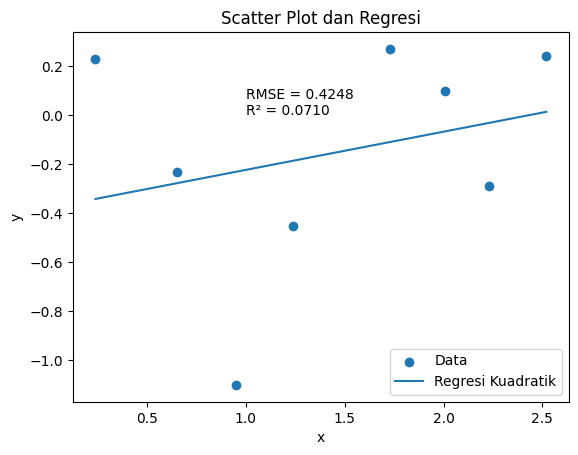

In [50]:
# Buat range x untuk kurva
x_plot = np.linspace(min(x), max(x), 100)
y_plot = a_linreg + b_linreg * x_plot

# Plot scatter
plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_plot, label="Regresi Kuadratik")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot dan Regresi")
text_str = f"RMSE = {rmse_linreg:.4f}\nR² = {r2_linreg:.4f}"
plt.text(1, 0, text_str)
plt.legend()
plt.show()

## Regresi Nonlinear: Kuadratik (Polinomial Orde 2)
Model:
$$
f(x) = a + bx + cx^2
$$

Fungsi Error (Least Squares). Turunan parsial terhadap parameter:
$$
\frac{\partial \Phi(a,b,c)}{\partial a} = \sum_{i=1}^{n} (a + b x_i + c x_i^2 - y_i) = 0
$$
$$
\frac{\partial \Phi(a,b,c)}{\partial b} = \sum_{i=1}^{n} (a + b x_i + c x_i^2 - y_i)x_i = 0
$$
$$
\frac{\partial \Phi(a,b,c)}{\partial c} = \sum_{i=1}^{n} (a + b x_i + c x_i^2 - y_i)x_i^2 = 0
$$

Persamaan Normal. Diperoleh sistem persamaan:
$$
a n + b \sum x_i + c \sum x_i^2 = \sum y_i
$$
$$
a \sum x_i + b \sum x_i^2 + c \sum x_i^3 = \sum x_i y_i
$$
$$
a \sum x_i^2 + b \sum x_i^3 + c \sum x_i^4 = \sum x_i^2 y_i
$$

Hitung komponen berikut:
$$\sum x_i, \sum x_i^2, \sum x_i^3, \sum x_i^4$$
$$ \sum y_i, \sum x_i y_i, \sum x_i^2 y_i$$

In [51]:
def polynomial_regression(x,y): 
    n = len(x)
    # Hitung semua komponen
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x**2)
    sum_x3 = np.sum(x**3)
    sum_x4 = np.sum(x**4)
    sum_xy = np.sum(x * y)
    sum_x2y = np.sum(x**2 * y)
    # Bentuk sistem persamaan
    A = np.array([
        [n, sum_x, sum_x2],
        [sum_x, sum_x2, sum_x3],
        [sum_x2, sum_x3, sum_x4]
    ])
    b_vec = np.array([sum_y, sum_xy, sum_x2y])
    a, b, c = gauss_elimination(A, b_vec)

    #Evaluasi
    y_pred = a + b * x + c * x**2
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)

    return a, b, c, rmse, r2

In [52]:
a_polreg, b_polreg, c_polreg, rmse_polreg, r2_polreg = polynomial_regression(x, y)
print("Hasil:")
print(f"a = {a_polreg:.4f}")
print(f"b = {b_polreg:.4f}")
print(f"c = {c_polreg:.4f}")
print("\nPersamaan regresi:")
print(f"f(x,t) = {a_polreg:.4f} + ({b_polreg:.4f})x + ({c_polreg:.4f})x^2")

Augmented matrix awal:
[[ 8.         11.57       21.2765     -1.23      ]
 [11.57       21.2765     43.443341   -1.0711    ]
 [21.2765     43.443341   93.69771701 -0.474549  ]]

R2 = R2 - (1.446)R1
R3 = R3 - (2.660)R1
Matrix setelah eliminasi:
[[ 8.         11.57       21.2765     -1.23      ]
 [ 0.          4.5433875  12.67220287  0.7077875 ]
 [ 0.         12.67220287 37.11153548  2.79671287]]

R3 = R3 - (2.789)R2
Matrix setelah eliminasi:
[[ 8.         11.57       21.2765     -1.23      ]
 [ 0.          4.5433875  12.67220287  0.7077875 ]
 [ 0.          0.          1.76682282  0.82258525]]

Hasil:
a = 0.2608
b = -1.1428
c = 0.4656

Persamaan regresi:
f(x,t) = 0.2608 + (-1.1428)x + (0.4656)x^2


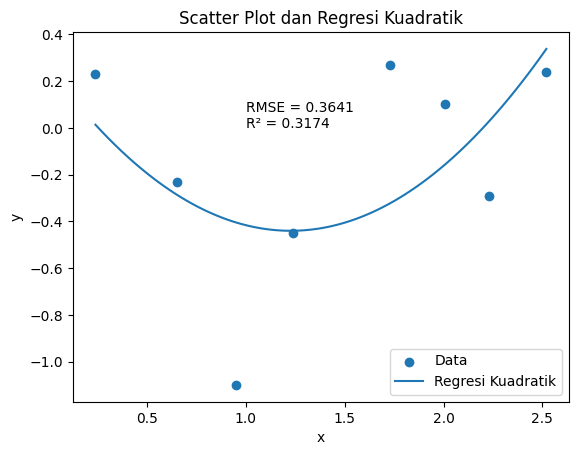

In [53]:
# Buat range untuk kurva 
x_plot = np.linspace(min(x), max(x), 100)
y_plot = a_polreg + b_polreg * x_plot + c_polreg * x_plot**2

# Plot scatter
plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_plot, label="Regresi Kuadratik")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot dan Regresi Kuadratik")
text_str = f"RMSE = {rmse_polreg:.4f}\nR² = {r2_polreg:.4f}"
plt.text(1, 0, text_str)
plt.legend()
plt.show()

## Regresi Nonlinear

Model:
$$
f(x) = a \ln(x) + b \cos(x) + c e^x
$$

Fungsi Error (Least Squares). Turunan parsial terhadap parameter:
$$
\frac{\partial \Phi}{\partial a} = 2 \sum_{i=1}^{n} (a \ln x_i + b \cos x_i + c e^{x_i} - y_i)\ln x_i = 0
$$
$$
\frac{\partial \Phi}{\partial b} = 2 \sum_{i=1}^{n} (a \ln x_i + b \cos x_i + c e^{x_i} - y_i)\cos x_i = 0
$$
$$
\frac{\partial \Phi}{\partial c} = 2 \sum_{i=1}^{n} (a \ln x_i + b \cos x_i + c e^{x_i} - y_i)e^{x_i} = 0
$$

Persamaan Normal. Diperoleh sistem persamaan:
$$
a \sum (\ln x_i)^2 + b \sum (\ln x_i \cos x_i) + c \sum (\ln x_i e^{x_i}) = \sum (y_i \ln x_i)
$$
$$
a \sum (\ln x_i \cos x_i) + b \sum (\cos x_i)^2 + c \sum (\cos x_i e^{x_i}) = \sum (y_i \cos x_i)
$$
$$
a \sum (\ln x_i e^{x_i}) + b \sum (\cos x_i e^{x_i}) + c \sum (e^{x_i})^2 = \sum (y_i e^{x_i})
$$

Hitung komponen:
$$\sum (\ln x_i)^2,
\sum (\ln x_i \cos x_i),
\sum (\ln x_i e^{x_i}),
\sum (\cos x_i)^2,
\sum (\cos x_i e^{x_i})$$
$$\sum (e^{x_i})^2,
\sum (y_i \ln x_i),
\sum (y_i \cos x_i),
\sum (y_i e^{x_i})$$

In [54]:
def nonlinear_regression(x, y):
    n = len(x)
    # Komponen
    sum_lnx2 = np.sum((np.log(x))**2)
    sum_lnx_cosx = np.sum((np.log(x))*(np.cos(x)))
    sum_lnx_ex = np.sum((np.log(x))*(np.exp(x)))
    sum_y_lnx = np.sum((y)*(np.log(x)))
    sum_cosx2 = np.sum((np.cos(x))**2)
    sum_cosx_ex = np.sum((np.cos(x))*(np.exp(x)))
    sum_y_cosx = np.sum((y)*(np.cos(x)))
    sum_ex2 = np.sum((np.exp(x))**2)
    sum_y_ex = np.sum((y)*(np.exp(x)))

    A = np.array([
        [sum_lnx2,     sum_lnx_cosx, sum_lnx_ex],
        [sum_lnx_cosx, sum_cosx2,    sum_cosx_ex],
        [sum_lnx_ex,   sum_cosx_ex,  sum_ex2]
    ])
    b_vec = np.array([
        sum_y_lnx,
        sum_y_cosx,
        sum_y_ex
    ])
    a, b, c = gauss_elimination(A, b_vec)
    # Evaluasi
    y_pred = a * np.log(x) + b * np.cos(x) + c * np.exp(x)
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)

    return a, b, c, rmse, r2

In [55]:
a_nonlinreg, b_nonlinreg, c_nonlinreg, rmse_nonlinreg, r2_nonlinreg = nonlinear_regression(x, y)
print("Hasil:")
print(f"a = {a_nonlinreg:.4f}")
print(f"b = {b_nonlinreg:.4f}")
print(f"c = {c_nonlinreg:.4f}")

print("\nPersamaan regresi:")
print(f"f(x,t) = {a_nonlinreg:.4f}ln(x) + ({b_nonlinreg:.4f})cos(x) + ({c_nonlinreg:.4f})e^x")

Augmented matrix awal:
[[ 4.55642915e+00 -3.31546966e+00  2.52192221e+01 -6.24862590e-02]
 [-3.31546966e+00  3.26307022e+00 -1.44814951e+01 -8.48513886e-01]
 [ 2.52192221e+01 -1.44814951e+01  3.52388136e+02 -1.99228344e+00]]

R2 = R2 - (-0.728)R1
R3 = R3 - (5.535)R1
Matrix setelah eliminasi:
[[ 4.55642915e+00 -3.31546966e+00  2.52192221e+01 -6.24862590e-02]
 [ 0.00000000e+00  8.50580371e-01  3.86918323e+00 -8.93981793e-01]
 [ 0.00000000e+00  3.86918323e+00  2.12803136e+02 -1.64643041e+00]]

R3 = R3 - (4.549)R2
Matrix setelah eliminasi:
[[ 4.55642915e+00 -3.31546966e+00  2.52192221e+01 -6.24862590e-02]
 [ 0.00000000e+00  8.50580371e-01  3.86918323e+00 -8.93981793e-01]
 [ 0.00000000e+00  0.00000000e+00  1.95202708e+02  2.42018043e+00]]

Hasil:
a = -0.8881
b = -1.1074
c = 0.0124

Persamaan regresi:
f(x,t) = -0.8881ln(x) + (-1.1074)cos(x) + (0.0124)e^x


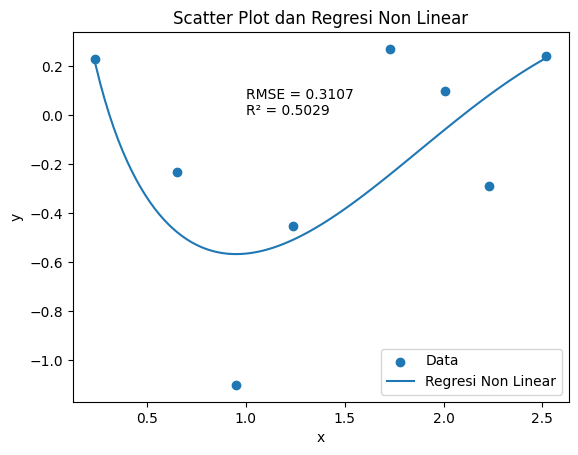

In [56]:
# Buat range x untuk kurva
x_plot = np.linspace(min(x), max(x), 100)
y_plot = a_nonlinreg * np.log(x_plot) + b_nonlinreg * np.cos(x_plot) + c_nonlinreg * np.exp(x_plot)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_plot, label="Regresi Non Linear")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot dan Regresi Non Linear")
text_str = f"RMSE = {rmse_nonlinreg:.4f}\nR² = {r2_nonlinreg:.4f}"
plt.text(1, 0, text_str)
plt.legend()
plt.show()

## Perbandingan Garis Regresi

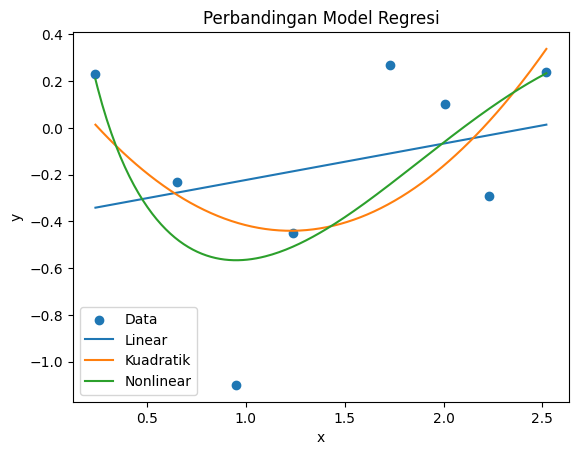

Perbandingan Model:
Linear: RMSE = 0.4248, R² = 0.0710
Kuadratik: RMSE = 0.3641, R² = 0.3174
Nonlinear: RMSE = 0.3107, R² = 0.5029


In [58]:
# Range x
x_plot = np.linspace(min(x), max(x), 200)
# Linear
y_linear = a_linreg + b_linreg * x_plot
# Kuadratik
y_quad = a_polreg + b_polreg * x_plot + c_polreg * x_plot**2
# Nonlinear
y_nonlin = a_nonlinreg*np.log(x_plot) + b_nonlinreg*np.cos(x_plot) + c_nonlinreg*np.exp(x_plot)

# Plot
plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_linear, label="Linear")
plt.plot(x_plot, y_quad, label="Kuadratik")
plt.plot(x_plot, y_nonlin, label="Nonlinear")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Perbandingan Model Regresi")
plt.legend()
plt.show()

# Bandingkan RMSE dan R²
print("Perbandingan Model:")
print(f"Linear: RMSE = {rmse_linreg:.4f}, R² = {r2_linreg:.4f}")
print(f"Kuadratik: RMSE = {rmse_polreg:.4f}, R² = {r2_polreg:.4f}")
print(f"Nonlinear: RMSE = {rmse_nonlinreg:.4f}, R² = {r2_nonlinreg:.4f}")